# Task 4: Predicting Insurance Claim Amounts
**Objective:** To estimate medical insurance claim amounts based on personal data using a Linear Regression model.
**Dataset:** Medical Cost Personal Dataset (includes age, sex, bmi, children, smoker status, and region).

In [1]:
# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Medical Cost Personal Dataset directly from a reliable open-source GitHub repo
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

# Display the first 5 rows to make sure it loaded correctly
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


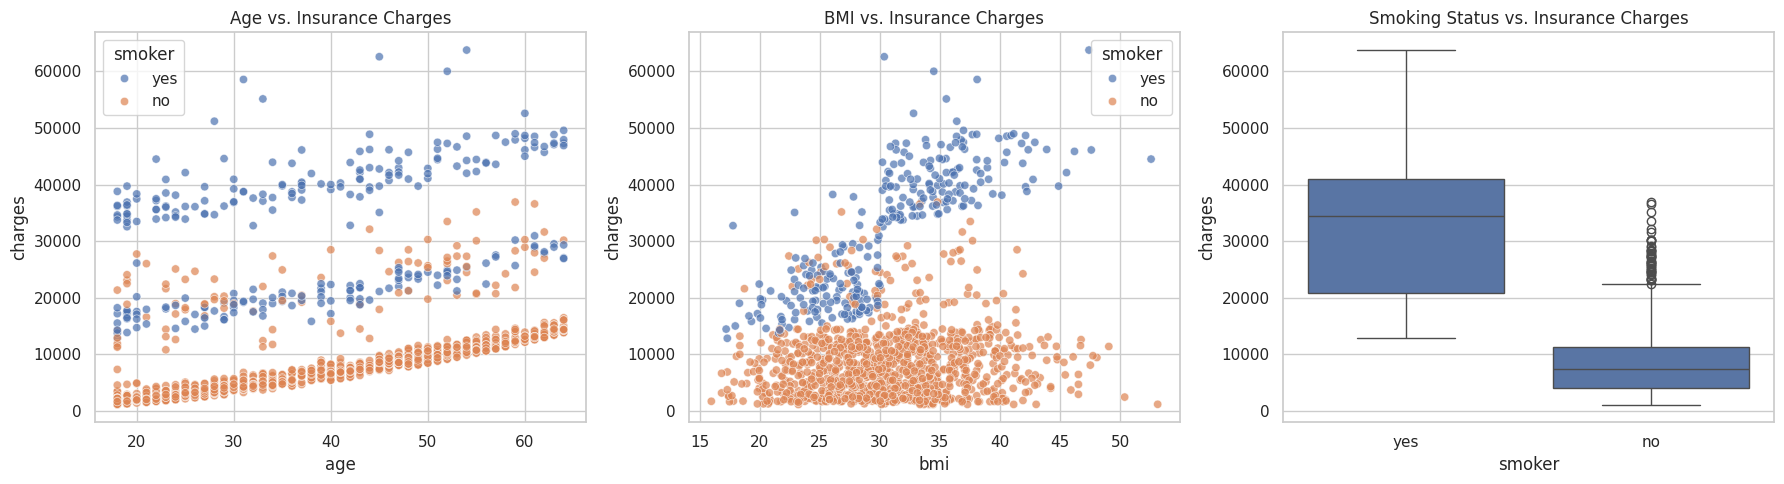

In [2]:
# Set up the visual style for our charts
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Age vs Charges (Scatter plot)
sns.scatterplot(ax=axes[0], data=df, x='age', y='charges', hue='smoker', alpha=0.7)
axes[0].set_title('Age vs. Insurance Charges')

# 2. BMI vs Charges (Scatter plot)
sns.scatterplot(ax=axes[1], data=df, x='bmi', y='charges', hue='smoker', alpha=0.7)
axes[1].set_title('BMI vs. Insurance Charges')

# 3. Smoking Status vs Charges (Box plot)
sns.boxplot(ax=axes[2], data=df, x='smoker', y='charges')
axes[2].set_title('Smoking Status vs. Insurance Charges')

# Display the charts neatly
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# 1. Data Preparation: Convert text columns (sex, smoker, region) into numbers
# drop_first=True prevents redundant columns (e.g., if it's not 'smoker_yes', it must be 'no')
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Separate our Features (X) from our Target (y)
X = df_encoded.drop('charges', axis=1) # Features: Everything except the target
y = df_encoded['charges']              # Target: Only the insurance charges

# 3. Split the data: 80% for training the model, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the first few rows of our new training features to confirm it worked
X_train.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Initialize the Linear Regression model
model = LinearRegression()

# 2. Train (fit) the model using our training data
model.fit(X_train, y_train)

# 3. Make predictions on our testing data
y_pred = model.predict(X_test)

# 4. Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Mean Absolute Error (MAE): $4,181.19
Root Mean Squared Error (RMSE): $5,796.28


### Conclusion
Based on the Exploratory Data Analysis, **smoking status** is the most significant factor driving up medical insurance charges, with age and BMI also showing positive correlations.

The Linear Regression model achieved a Mean Absolute Error (MAE) of ~$4,181 and a Root Mean Squared Error (RMSE) of ~$5,796. The higher RMSE suggests that while the model captures the general trend well, there are large outliers (likely extreme medical events) that a simple linear model struggles to predict perfectly.